In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

In [2]:
#import importlib
#importlib.reload(tm)

In [3]:

n = 1000
x = np.random.normal(0, 0.01, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.01,n)
df1 = pd.DataFrame()
df1['x'] = x
df1['y'] = y
df1.index = pd.date_range('2000-01-01', freq = 'D', periods = n)

n = 1000
x = np.random.normal(0, 0.03, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.03,n)
df2 = pd.DataFrame()
df2['y'] = y
df2['x'] = x
df2.index = pd.date_range('2002-01-01', freq = 'D', periods = n)


dataset = tm.Dataset()
dataset.add('strat1', df1)
dataset.add('strat2', df2)

model_set = tm.ModelSet()

base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model1 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat1', model1)     


base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model2 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat2', model2)    


model_set.estimate(dataset) 
model_set.view()



******* ModelSet *******

Model weights
strat1 0.8775760404020005
strat2 1.0489854906280696



-> For key strat1


* Model *
** Linear Regression **
Weights:  [1.84542833e-04 1.96498550e-01]
Variance:  9.960938569848801e-05


k:  33.1710587410603
Weight mean:  [0.]



-> For key strat2


* Model *
** Linear Regression **
Weights:  [-4.20812165e-05  2.05777495e-01]
Variance:  0.0009138146279111519


k:  33.1710587410603
Weight mean:  [0.]


*************************


In [4]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = dataset, 
        modelset = model_set,            
        n_paths = 1,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.19it/s]


In [5]:
paths

[{'strat1':                    y         x  msidx         s        pw        w_y
  2000-01-01  0.003121  0.008897    0.0  0.034013  0.565885  10.896776
  2000-01-02 -0.022972 -0.007355    0.0  0.265599  0.565885 -11.561990
  2000-01-03  0.007003  0.007623    0.0  0.064183  0.565885   9.165514
  2000-01-04 -0.007274 -0.005523    0.0  0.066037  0.565885  -9.077973
  2000-01-05  0.000422  0.017139    0.0  0.009082  0.565885  21.514622
  ...              ...       ...    ...       ...       ...        ...
  2002-09-22 -0.010046  0.000844    0.0 -0.063805  0.930109   6.351131
  2002-09-23  0.003364 -0.004346    0.0 -0.016227  0.930109  -4.823588
  2002-09-24 -0.004720 -0.002758    0.0  0.006620  0.930109  -1.402667
  2002-09-25 -0.002860 -0.008305    0.0  0.037650  0.930109 -13.162239
  2002-09-26 -0.003974 -0.002030    0.0 -0.000666  0.930109   0.167631
  
  [1000 rows x 6 columns],
  'strat2':                    y         x  msidx         s        pw        w_y
  2002-01-01 -0.086172 -0.0

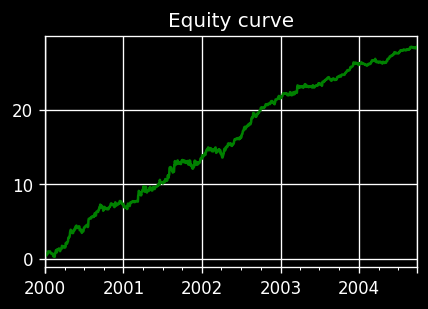

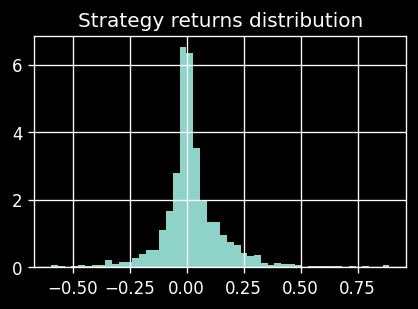

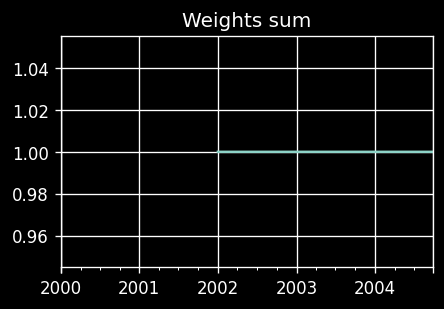

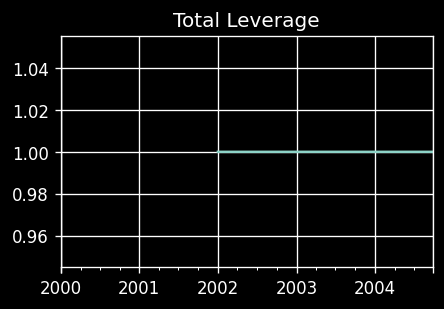

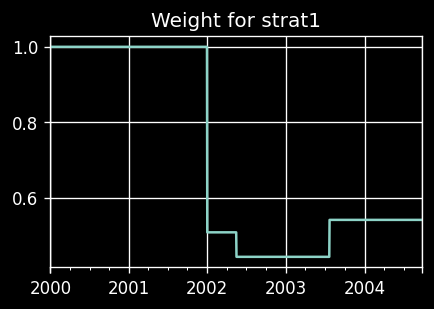

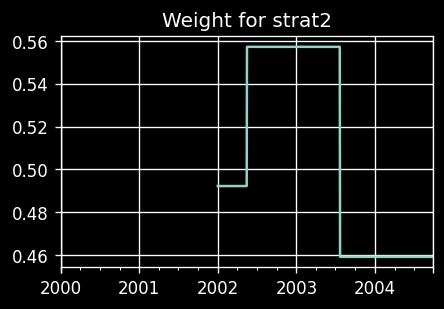

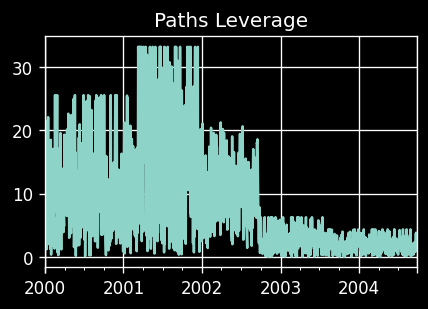

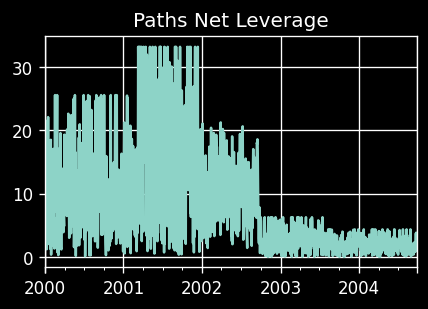

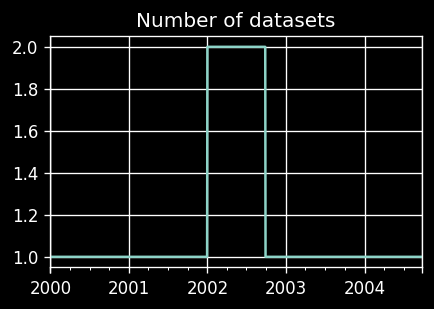

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


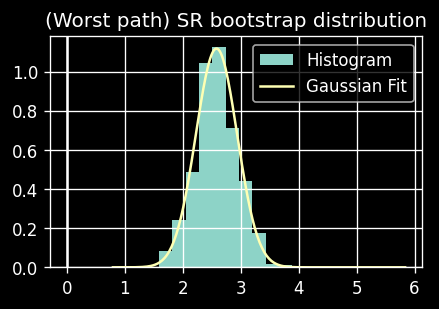


** PERFORMANCE SUMMARY **

Return:  5.742006483839666
Standard deviation:  2.1958121757297153
Sharpe:  2.6149807106937435



,path_1
1999-12-31,0.265599
2000-01-03,0.064183
2000-01-04,0.066037
2000-01-05,0.009082
2000-01-06,0.084914
...,...
2004-09-20,-0.036380
2004-09-21,-0.055196
2004-09-22,0.151345
2004-09-23,-0.000969


In [6]:
paths.portfolio_post_process(pct_fee = 0)
